# Emotion and Gender Recognition

In [ ]:
# Uncomment the following line to install dependencies from requirements.txt
# !pip install -r requirements.txt
from IPython.display import clear_output
clear_output()

In [ ]:
import os
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from pretrained_vggish import VGGish
from evaluations import *
from tcn import TCNBlock
from lightning import SpeechClassifier, SpeechDataModule, download_ravdess, TrainMetricsCallback, ValidationMetricsCallback
from torch.utils.data import Subset, DataLoader 

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU")
else:  
    device = torch.device("cpu")
    print("Using CPU")
    
%matplotlib inline

Using Apple Silicon GPU


# Dataset

In [ ]:
model_urls = {
    'vggish': 'https://github.com/harritaylor/torchvggish/'
              'releases/download/v0.1/vggish-10086976.pth',
    'pca': 'https://github.com/harritaylor/torchvggish/'
           'releases/download/v0.1/vggish_pca_params-970ea276.pth'
}

speech_data_dir = './ravdess_speech'
song_data_dir = './ravdess_song'
download_ravdess(speech_data_dir, song_data_dir)
# Keep a separate cache directory for non-postprocessed embeddings.
embedding_cache_dir = './embeddings_raw'
# Dataset Class Preprocesses 
clear_output()

In [4]:
# Preprocessing in VGGish is turned off so that we can handle it ourselves in the LightningModule, allowing for more flexibility and control over the input data format.
vggish = VGGish(pretrained=True, progress=True, postprocess=False, urls=model_urls, device=device)

In [5]:
if device == torch.device("cuda"):
    num_workers = 4
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

# If you want to try with the ravdess_song dataset, change the data_dir argument to song_data_dir
data_module = SpeechDataModule(
    data_dir=speech_data_dir, 
    batch_size=32,
    train_split=0.8, 
    num_workers=num_workers, 
    pin_memory=pin_memory,
    embeddings_source='cached', #raw if you want calculate embeddings on the fly, cached if you want to precompute embeddings on dataset initialization. 
    cache_dir=embedding_cache_dir,
    vggish_model=vggish,
    device=device
)

data_module.setup()
print(f"Train samples: {len(data_module.dataset)}")

data_loader_train = data_module.train_dataloader()
print(f"Training batches: {len(data_loader_train)}")

data_loader_eval = data_module.val_dataloader()
print(f"Validation batches: {len(data_loader_eval)}")


Indexed 1440 unique audio files from ./ravdess_speech (removed 1440 duplicates).
Train samples: 1440
Training batches: 36
Validation batches: 9


In [6]:
embeddings = torch.load(os.path.join(embedding_cache_dir, 'sample_00000.pt'), map_location=device)

print(embeddings.keys())
print(embeddings['embedding'].shape)

dict_keys(['embedding', 'gender_label', 'emotion_label', 'source_path', 'source_index'])
torch.Size([4, 128])


# VGG

## t-SNE Analysis

Found 1440 embedding files.
torch.Size([1440, 4, 128])
Saved t-SNE to emotion_vggish_embeddings_tsne.png


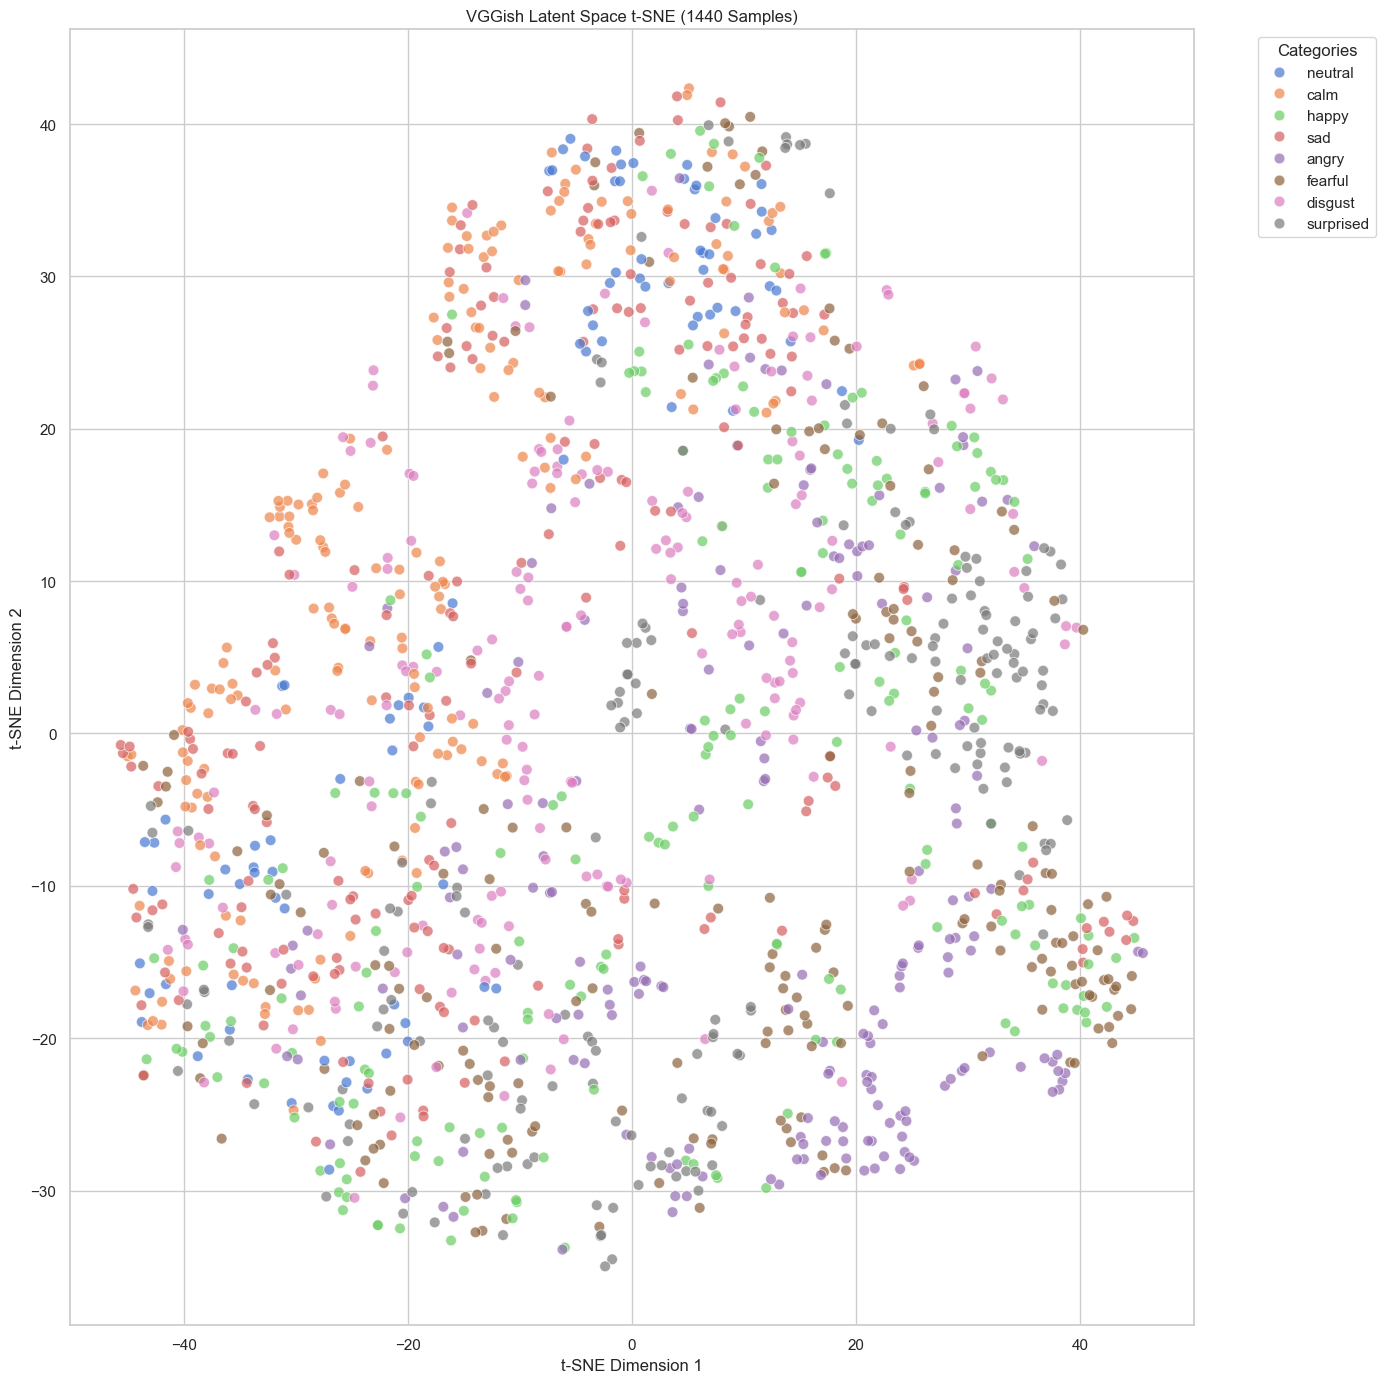

Saved t-SNE to gender_vggish_embeddings_tsne.png


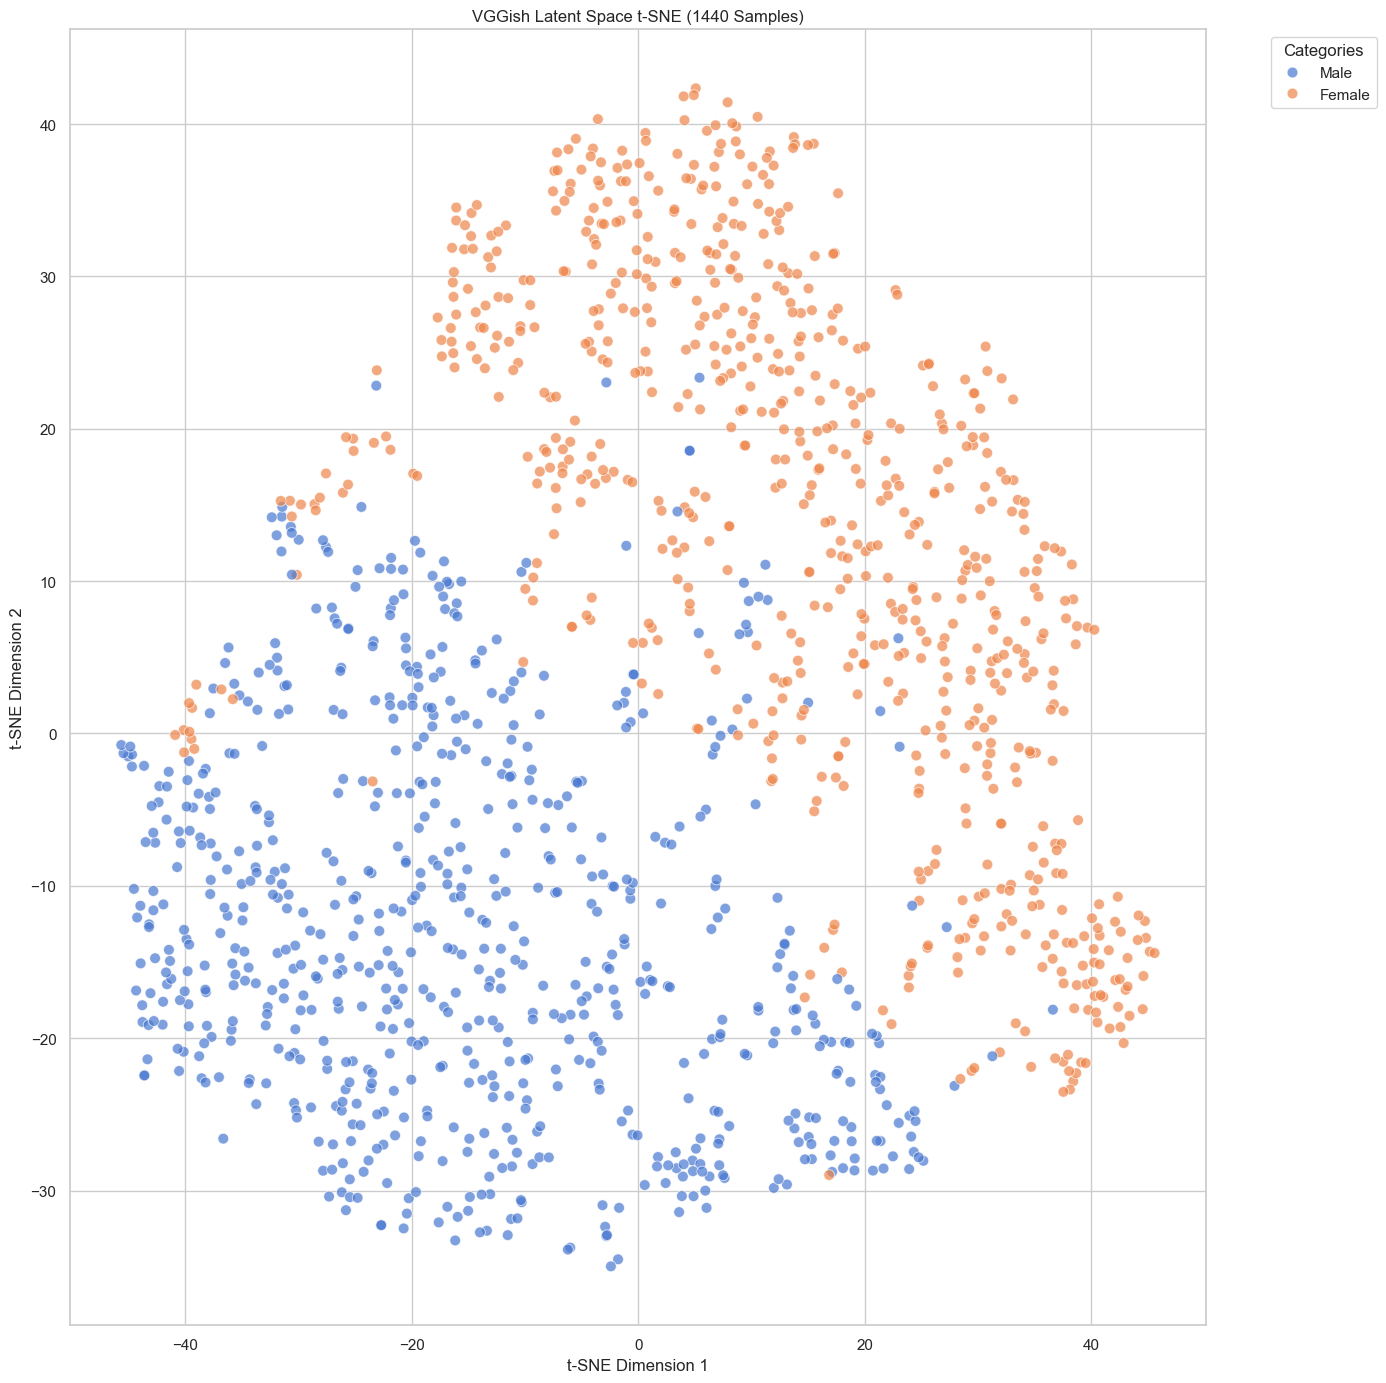

In [ ]:
import glob

embedding_files = sorted(glob.glob(data_module.cache_dir + '/*.pt'))
print(f"Found {len(embedding_files)} embedding files.")
if not embedding_files:
    raise FileNotFoundError('No saved emotion embeddings found. Run the preprocessing cell first.')

saved_items = [torch.load(path, map_location='cpu') for path in embedding_files]

# Stack creates shape [1440, 4, 128]
output = torch.stack([item['embedding'].to(torch.float32) for item in saved_items], dim=0)

if output.ndim == 3:
    output = output.mean(dim=1) 

emotion_labels = torch.stack([item['emotion_label'].to(torch.long).reshape(()) for item in saved_items], dim=0).numpy()
gender_labels = torch.stack([item['gender_label'].to(torch.long).reshape(()) for item in saved_items], dim=0).numpy()

# Drop non-finite rows before t-SNE to avoid sklearn errors
finite_mask = torch.isfinite(output).all(dim=1)
if not finite_mask.all():
    dropped = int((~finite_mask).sum().item())
    print(f'Dropping {dropped} rows with NaN/Inf embeddings before t-SNE.')
    output = output[finite_mask]
    emotion_labels = emotion_labels[finite_mask.numpy()]
    gender_labels = gender_labels[finite_mask.numpy()] 

# Plot Emotion
visualize_embeddings_tsne(
    emotion_labels,
    output.numpy(),
    output_file="emotion_vggish_embeddings_tsne.png",
    sample_size=1440,
    annotate=False, 
    label_map=data_module.emotion_map
)

# Plot Gender
visualize_embeddings_tsne(
    gender_labels,
    output.numpy(),
    output_file="gender_vggish_embeddings_tsne.png",
    sample_size=1440,
    annotate=False, # Set to False!
    label_map={0: 'Male', 1: 'Female'}
)

# Temporal Convolutional Network - Binary and Multilabel Classification
- Cell below sets up the TCN block used for the full system at the bottom of this notebook. 

In [8]:
learning_rate = 8.4e-4

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=False,
    mode='min'
)

pl.seed_everything(42)

Seed set to 42


42

# Ablation Study
- Isolate the TCN Model and feed an embedding matrix with random Gaussian noise rather than the original embedding matrix.

In [9]:
raw_spec_module = SpeechDataModule(
    data_dir=speech_data_dir, 
    batch_size=32,
    train_split=0.8,
    num_workers=num_workers,
    pin_memory=pin_memory,
    embeddings_source='cached', #raw if you want calculate embeddings on the fly, cached if you want to precompute embeddings on dataset initialization.
    cache_dir=embedding_cache_dir,
    vggish_model=vggish,
    device=device, 
)

raw_spec_module.setup()
print(f"Train samples: {len(raw_spec_module.dataset)}")

raw_loader_train = raw_spec_module.train_dataloader()
print(f"Training batches: {len(raw_loader_train)}")

raw_loader_eval = raw_spec_module.val_dataloader()
print(f"Validation batches: {len(raw_loader_eval)}")

Indexed 1440 unique audio files from ./ravdess_speech (removed 1440 duplicates).
Train samples: 1440
Training batches: 36
Validation batches: 9


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ vggish            │ VGGish                    │ 72.1 M │ train │     0 │
│ 1  │ temporal_backbone │ TCNBlock                  │ 45.2 K │ train │     0 │
│ 2  │ gender_head       │ Linear                    │     65 │ train │     0 │
│ 3  │ emotion_head      │ Linear                    │    520 │ train │     0 │
│ 4  │ mc_conf_matrix    │ MulticlassConfusionMatrix │      0 │ train │     0 │
│ 5  │ bc_conf_matrix    │ BinaryConfusionMatrix     │      0 │ train │     0 │
│ 6  │ acc_emotion       │ MulticlassAccuracy        │      0 │ train │     0 │
│ 7  │ acc_gender        │ BinaryAccuracy            │      0 │ train │     0 │
│ 8  │ f1_emotion        │ MulticlassF1Score         │      0 │ train │     0 │
│ 9  │ precision_emotion │ MulticlassPrecision       │      0 │ train │     0 │
│ 10 │ recall_emotion    │ MulticlassRecall          │      0 │ train │     0 │
│ 11 │ f1_gender         │ BinaryF1Score             │      0 │ train │     0 │
│ 12 │ precision_gender  │ BinaryPrecision           │      0 │ train │     0 │
│ 13 │ recall_gender     │ BinaryRecall              │      0 │ train │     0 │
│ 14 │ gender_criterion  │ BCEWithLogitsLoss         │      0 │ train │     0 │
│ 15 │ emotion_criterion │ CrossEntropyLoss          │      0 │ train │     0 │
└────┴───────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 45.8 K                                                                                           
Non-trainable params: 72.1 M                                                                                       
Total params: 72.2 M                                                                                               
Total estimated model params size (MB): 288                                                                        
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/dl4am/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

==============================

--> F1 Score: 0.5102

--> Precision: 0.5000

--> Recall: 0.5208

`Trainer.fit` stopped: `max_epochs=50` reached.


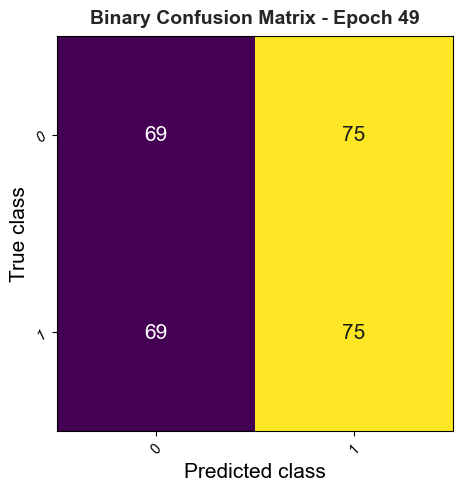

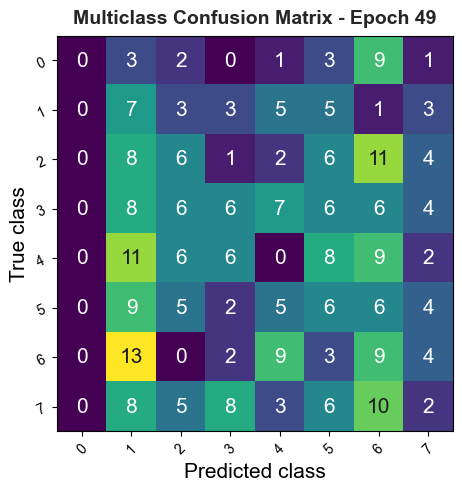

In [10]:
gaussian_test_model = TCNBlock(
    in_channels=128,
    out_channels=64,
    kernel_size=3,
    dilation=2,
    dropout_rate=0.1
).to(device)

isolated_tcn_classifier = SpeechClassifier(
    pretrained_vggish=vggish,
    tcn_model=gaussian_test_model,
    learning_rate=learning_rate,
    device=device,
    emotion_map=raw_spec_module.emotion_map,
    gender_loss_weight=0.5,
    emotion_loss_weight=1.0,
    activate_ablation=True # Activates feeding Gaussian noise to the TCN to simulate the ablation of VGGish embeddings. Set to cache to speed up loading since we are only focused on the TCN in this ablation test.
)

isolation_metrics_callback = ValidationMetricsCallback()

isolated_trainer = pl.Trainer(
    max_epochs=50,
    accelerator=device.type if device.type != 'mps' else 'gpu',  # Use 'gpu' for MPS in PyTorch Lightning
    devices=1 if device.type != 'mps' else 1,  # Let Lightning handle device count for MPS
    logger=[
        pl.loggers.TensorBoardLogger("tb_logs", name="speech_emotion_classifier"),
        pl.loggers.CSVLogger("csv_logs", name="speech_emotion_classifier")
    ],
    callbacks=[isolation_metrics_callback]
)

isolated_trainer.fit(isolated_tcn_classifier, raw_spec_module)    

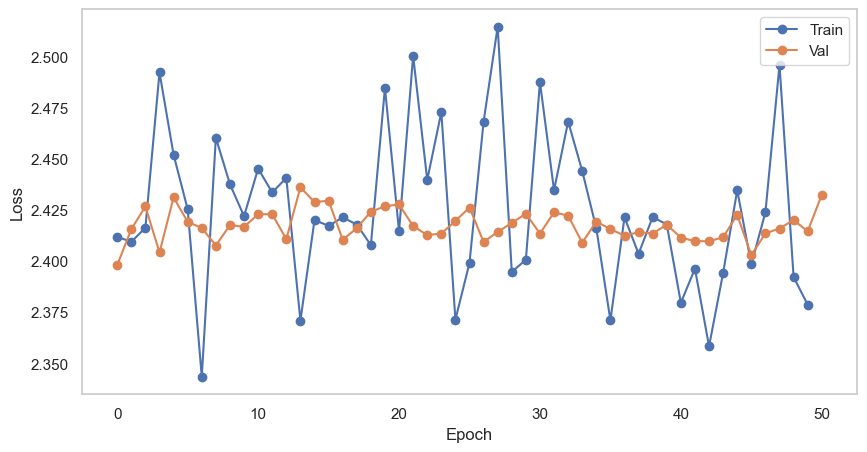

In [11]:
# Plot after training
plt.figure(figsize=(10, 5))
plt.plot(isolation_metrics_callback.train_losses, label='Train', marker='o')
plt.plot(isolation_metrics_callback.val_losses, label='Val', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Overfitting Experiment
- Overfitting the model to 1 batch.

In [19]:
train_ds = data_module.train_ds
balanced_indices = []

# For each gender (0, 1) and emotion (0-7), collect 2 samples
for gender_id in range(2):
    for emotion_id in range(8):
        gender_name = 'Male' if gender_id == 0 else 'Female'
        emotion_name = data_module.emotion_map[emotion_id]
        
        # Find samples matching this gender/emotion combo
        matching_indices = []
        for idx in train_ds.indices:
            item = torch.load(data_module.cache_files[idx], map_location='cpu')
            if item['gender_label'] == gender_id and item['emotion_label'] == emotion_id:
                matching_indices.append(idx)
        
        # Take first 2 samples from this combo (2 * 2 * 8 = 32 total)
        selected = matching_indices[:2]
        balanced_indices.extend(selected)

print(f"\nTotal balanced subset size: {len(balanced_indices)}")
balanced_subset = Subset(data_module, balanced_indices)
balanced_loader = DataLoader(balanced_subset, batch_size=32, shuffle=False)

of_early_stop_callback = EarlyStopping(
    monitor='train_loss',
    patience=20,
    verbose=False,
    mode='min'
)

tcn_model_of = TCNBlock(
    in_channels=128,
    out_channels=64,
    kernel_size=3,
    dilation=2,
    dropout_rate=0.0
).to(device)

of_classifier = SpeechClassifier(
    pretrained_vggish=vggish,
    tcn_model=tcn_model_of,
    learning_rate=learning_rate,  # try 1e-3 if unstable
    device=device,
    emotion_map=data_module.emotion_map,
    gender_loss_weight=1.0,   
    emotion_loss_weight=1.0
)

train_metrics_callback = TrainMetricsCallback()

of_trainer = pl.Trainer(
    max_epochs=150,
    accelerator=device.type if device.type != "mps" else "gpu",
    devices=1,
    logger=[
        pl.loggers.TensorBoardLogger("tb_logs", name="overfit_emotion_debug"),
        pl.loggers.CSVLogger("csv_logs", name="overfit_emotion_debug"),
    ],
    callbacks=[train_metrics_callback, of_early_stop_callback],
    overfit_batches=1,
    limit_val_batches=0,      # no val noise during overfit test
    num_sanity_val_steps=0,
    log_every_n_steps=1,
    gradient_clip_val=1.0
)

of_trainer.fit(of_classifier, train_dataloaders=balanced_loader)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(overfit_batches=1)` was configured so 1 batch will be used.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Total balanced subset size: 32


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ vggish            │ VGGish                    │ 72.1 M │ train │     0 │
│ 1  │ temporal_backbone │ TCNBlock                  │ 45.2 K │ train │     0 │
│ 2  │ gender_head       │ Linear                    │     65 │ train │     0 │
│ 3  │ emotion_head      │ Linear                    │    520 │ train │     0 │
│ 4  │ mc_conf_matrix    │ MulticlassConfusionMatrix │      0 │ train │     0 │
│ 5  │ bc_conf_matrix    │ BinaryConfusionMatrix     │      0 │ train │     0 │
│ 6  │ acc_emotion       │ MulticlassAccuracy        │      0 │ train │     0 │
│ 7  │ acc_gender        │ BinaryAccuracy            │      0 │ train │     0 │
│ 8  │ f1_emotion        │ MulticlassF1Score         │      0 │ train │     0 │
│ 9  │ precision_emotion │ MulticlassPrecision       │      0 │ train │     0 │
│ 10 │ recall_emotion    │ MulticlassRecall          │      0 │ train │     0 │
│ 11 │ f1_gender         │ BinaryF1Score             │      0 │ train │     0 │
│ 12 │ precision_gender  │ BinaryPrecision           │      0 │ train │     0 │
│ 13 │ recall_gender     │ BinaryRecall              │      0 │ train │     0 │
│ 14 │ gender_criterion  │ BCEWithLogitsLoss         │      0 │ train │     0 │
│ 15 │ emotion_criterion │ CrossEntropyLoss          │      0 │ train │     0 │
└────┴───────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 45.8 K                                                                                           
Non-trainable params: 72.1 M                                                                                       
Total params: 72.2 M                                                                                               
Total estimated model params size (MB): 288                                                                        
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=150` reached.


# Full System Training and Evaluation

In [13]:
tcn_model = TCNBlock(
    in_channels=128,
    out_channels=64,
    kernel_size=3,
    dilation=2,
    dropout_rate=0.1
).to(device)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/miniconda3/envs/dl4am/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/jonathanferraro/Documents/Code/ECS7013P/checkpoints exists and is not empty.


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ vggish            │ VGGish                    │ 72.1 M │ train │     0 │
│ 1  │ temporal_backbone │ TCNBlock                  │ 45.2 K │ train │     0 │
│ 2  │ gender_head       │ Linear                    │     65 │ train │     0 │
│ 3  │ emotion_head      │ Linear                    │    520 │ train │     0 │
│ 4  │ mc_conf_matrix    │ MulticlassConfusionMatrix │      0 │ train │     0 │
│ 5  │ bc_conf_matrix    │ BinaryConfusionMatrix     │      0 │ train │     0 │
│ 6  │ acc_emotion       │ MulticlassAccuracy        │      0 │ train │     0 │
│ 7  │ acc_gender        │ BinaryAccuracy            │      0 │ train │     0 │
│ 8  │ f1_emotion        │ MulticlassF1Score         │      0 │ train │     0 │
│ 9  │ precision_emotion │ MulticlassPrecision       │      0 │ train │     0 │
│ 10 │ recall_emotion    │ MulticlassRecall          │      0 │ train │     0 │
│ 11 │ f1_gender         │ BinaryF1Score             │      0 │ train │     0 │
│ 12 │ precision_gender  │ BinaryPrecision           │      0 │ train │     0 │
│ 13 │ recall_gender     │ BinaryRecall              │      0 │ train │     0 │
│ 14 │ gender_criterion  │ BCEWithLogitsLoss         │      0 │ train │     0 │
│ 15 │ emotion_criterion │ CrossEntropyLoss          │      0 │ train │     0 │
└────┴───────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 45.8 K                                                                                           
Non-trainable params: 72.1 M                                                                                       
Total params: 72.2 M                                                                                               
Total estimated model params size (MB): 288                                                                        
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/dl4am/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

==============================

--> F1 Score: 0.9726

--> Precision: 0.9726

--> Recall: 0.9726

`Trainer.fit` stopped: `max_epochs=50` reached.


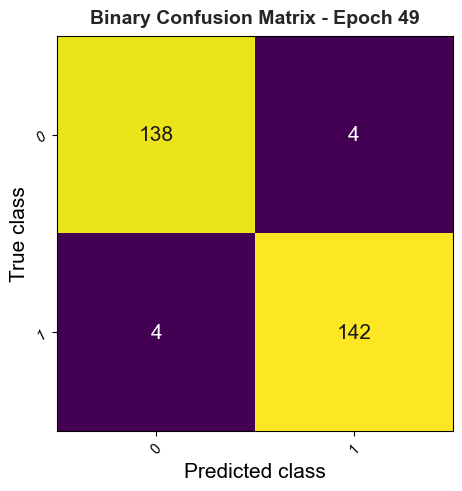

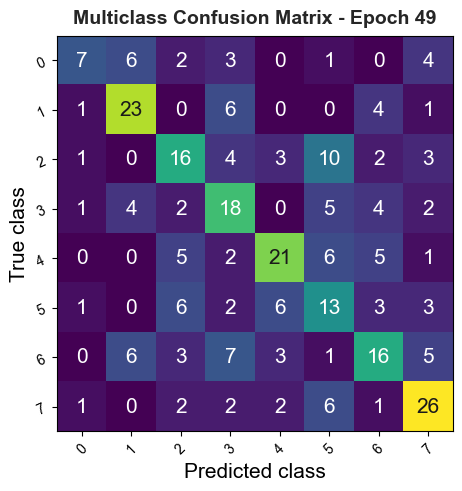

In [14]:
classifier = SpeechClassifier(
    pretrained_vggish=vggish,
    tcn_model=tcn_model,
    learning_rate=learning_rate,
    device=device,
    emotion_map=data_module.emotion_map,
    gender_loss_weight=0.5,
    emotion_loss_weight=1.0
)

checkpoint = ModelCheckpoint(
    monitor='val_loss', 
    mode='min', 
    save_top_k=1, 
    dirpath='checkpoints', 
    filename='best-val-loss'
)

metrics_callback = ValidationMetricsCallback()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=device.type if device.type != 'mps' else 'gpu',  # Use 'gpu' for MPS in PyTorch Lightning
    devices=1 if device.type != 'mps' else 1,  # Let Lightning handle device count for MPS
    logger=[
        pl.loggers.TensorBoardLogger("tb_logs", name="speech_emotion_classifier"),
        pl.loggers.CSVLogger("csv_logs", name="speech_emotion_classifier")
    ],
    callbacks=[metrics_callback, checkpoint]
)

trainer.fit(classifier, data_module)    


In [ ]:
best_class = SpeechClassifier.load_from_checkpoint(
    checkpoint.best_model_path, 
    pretrained_vggish=vggish,
    tcn_model=tcn_model
).to(device)

eval_results = trainer.validate(
    best_class, dataloaders=data_module.val_dataloader())



Output()

/opt/miniconda3/envs/dl4am/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/miniconda3/envs/dl4am/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      val_emotion_acc      │    0.4804563522338867     │
│     val_emotion_loss      │    1.4215279817581177     │
│      val_gender_acc       │    0.9722222089767456     │
│      val_gender_loss      │    0.0766822025179863     │
│         val_loss          │    1.4982101917266846     │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      val_emotion_acc      │    0.4804563522338867     │
│     val_emotion_loss      │    1.4215279817581177     │
│      val_gender_acc       │    0.9722222089767456     │
│      val_gender_loss      │    0.0766822025179863     │
│         val_loss          │    1.4982101917266846     │
└───────────────────────────┴───────────────────────────┘